<a href="https://colab.research.google.com/github/aayshinde/Breast-Cancer-Malignancy-Prediction-Using-Cytological-Cell-Features-and-Machine-Learning/blob/main/BioInfProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If running in a fresh environment, install once:
# !pip install numpy pandas scikit-learn matplotlib seaborn xgboost

import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report, average_precision_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.base import clone

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
print("✅ Imports loaded")


✅ Imports loaded


In [ ]:
df = pd.read_csv("cancer.csv")
print("Shape:", df.shape)

df_clean = df.copy()

# Drop ID column if it exists
if 'id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['id'])

# Convert all features to numeric
for col in df_clean.columns:
    if col != 'classes':
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Missing values per column:")
print(df_clean.isna().sum())

# Split X & y
y = df_clean["classes"].astype(int)
X = df_clean.drop(columns=["classes"])
num_cols = X.columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Shape: (699, 11)
Missing values per column:
clump_thickness            0
unif_cell_size             0
unif_cell_shape            0
marg_adhesion              0
single_epith_cell_size     0
bare_nuclei               16
bland_chrom                0
norm_nucleoli              0
mitoses                    0
classes                    0
dtype: int64
Train: (559, 9) Test: (140, 9)


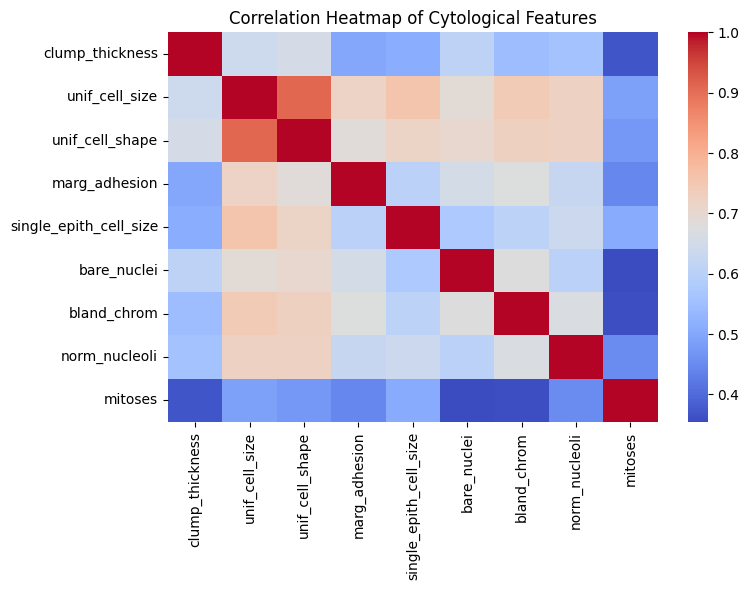

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Cytological Features")
plt.tight_layout()
plt.show()


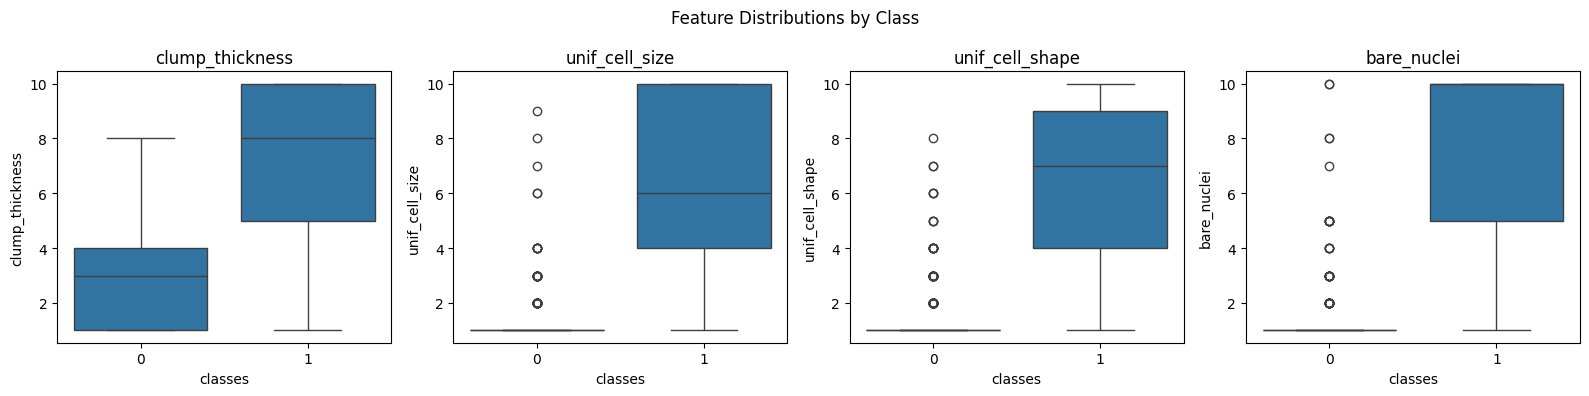

In [ ]:
features = ['clump_thickness', 'unif_cell_size', 'unif_cell_shape', 'bare_nuclei']

fig, axes = plt.subplots(1, len(features), figsize=(16, 4))
for ax, col in zip(axes, features):
    sns.boxplot(x=y_train, y=X_train[col], ax=ax)
    ax.set_title(col)

plt.suptitle("Feature Distributions by Class")
plt.tight_layout()
plt.show()


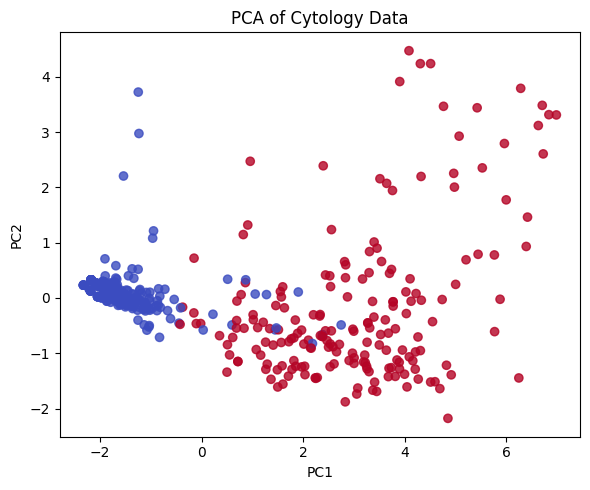

Explained variance: [0.65820661 0.08426502]


In [ ]:
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X_train)

sc = StandardScaler()
X_scaled = sc.fit_transform(X_imp)

pca = PCA(n_components=2, random_state=42)
PC = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(PC[:, 0], PC[:, 1], c=y_train, cmap="coolwarm", alpha=0.8)
plt.title("PCA of Cytology Data")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)


In [ ]:
# Scaling pipeline for LR and SVM
prep_scaled = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler())
    ]), num_cols)
])

# No scaling for RF/XGB
prep_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols)
])

pipelines = {
    "logreg": Pipeline([
        ("prep", prep_scaled),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),

    "rf": Pipeline([
        ("prep", prep_tree),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),

    "svm": Pipeline([
        ("prep", prep_scaled),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),

    "xgb": Pipeline([
        ("prep", prep_tree),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.8, eval_metric='logloss',
            random_state=42, n_jobs=-1
        ))
    ])
}

param_grids = {
    "logreg": {"clf__C": [0.3, 1, 3]},
    "rf": {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 8, 12]},
    "svm": {"clf__C": [0.5, 1, 2], "clf__gamma": ["scale", 0.05]},
    "xgb": {"clf__max_depth": [3, 4], "clf__learning_rate": [0.05, 0.1]}
}

print("✅ Pipelines ready")


✅ Pipelines ready


In [ ]:
results = {}
fitted = {}

for name, model in pipelines.items():
    print(f"\n=== Training {name.upper()} ===")

    grid = GridSearchCV(
        model, param_grids[name],
        cv=3, scoring='roc_auc', n_jobs=-1
    )
    grid.fit(X_train, y_train)

    fitted[name] = grid.best_estimator_
    proba = grid.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary')
    auc = roc_auc_score(y_test, proba)

    results[name] = [acc, prec, rec, f1, auc]

    print("Best Params:", grid.best_params_)
    print(f"AUC = {auc:.3f}")

df_results = pd.DataFrame(
    results, index=["Accuracy","Precision","Recall","F1","AUC"]
).T
display(df_results)

best_name = df_results["AUC"].idxmax()
best_model = fitted[best_name]
print("\n🏆 Best Model:", best_name.upper())



=== Training LOGREG ===
Best Params: {'clf__C': 0.3}
AUC = 0.995

=== Training RF ===
Best Params: {'clf__max_depth': 8, 'clf__n_estimators': 200}
AUC = 0.991

=== Training SVM ===
Best Params: {'clf__C': 0.5, 'clf__gamma': 0.05}
AUC = 0.992

=== Training XGB ===
Best Params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3}
AUC = 0.991


,Accuracy,Precision,Recall,F1,AUC
logreg,0.957143,0.937500,0.937500,0.937500,0.995245
rf,0.964286,0.938776,0.958333,0.948454,0.990829
svm,0.964286,0.938776,0.958333,0.948454,0.991621
xgb,0.957143,0.937500,0.937500,0.937500,0.990942



🏆 Best Model: LOGREG


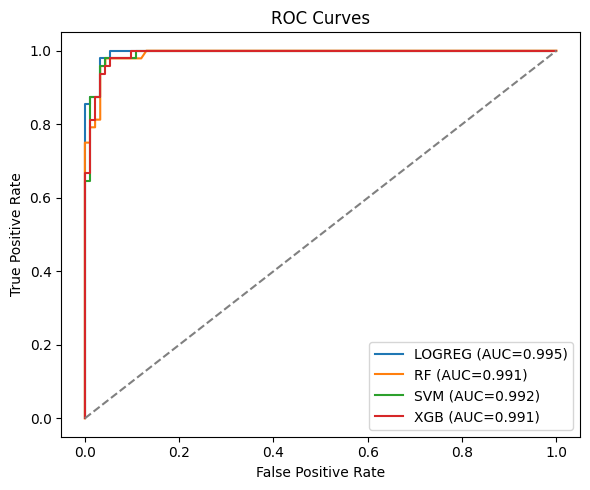

In [ ]:
plt.figure(figsize=(6, 5))

for name, model in fitted.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name.upper()} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


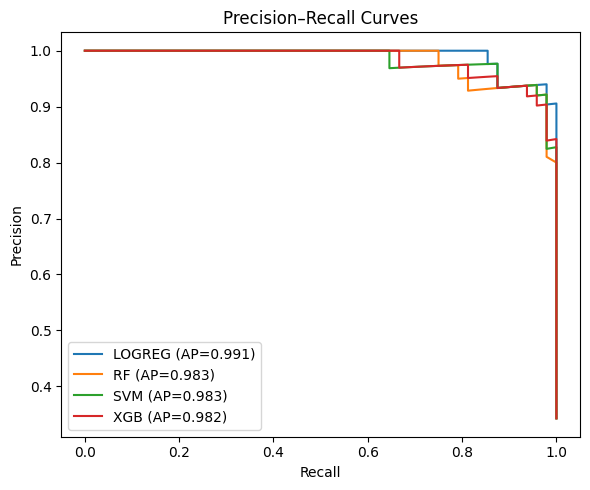

In [ ]:
plt.figure(figsize=(6, 5))

for name, model in fitted.items():
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f"{name.upper()} (AP={ap:.3f})")

plt.title("Precision–Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


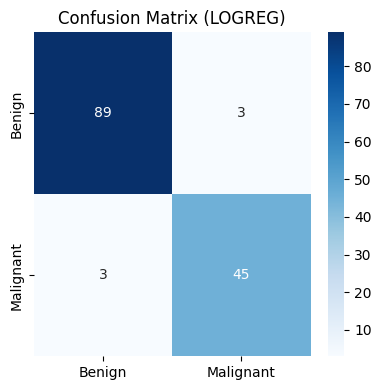

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



In [ ]:
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title(f"Confusion Matrix ({best_name.upper()})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred))


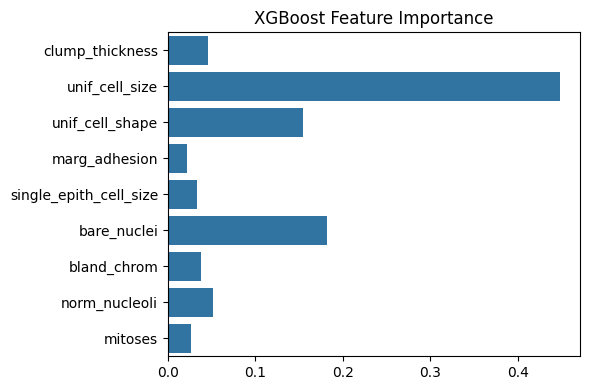

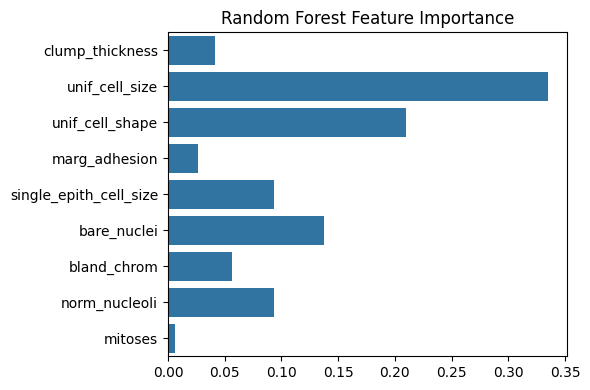

In [ ]:
# XGBoost importance
xgb_clf = fitted["xgb"].named_steps["clf"]
plt.figure(figsize=(6, 4))
sns.barplot(x=xgb_clf.feature_importances_, y=num_cols)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# Random Forest importance
rf_clf = fitted["rf"].named_steps["clf"]
plt.figure(figsize=(6, 4))
sns.barplot(x=rf_clf.feature_importances_, y=num_cols)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


,feature,importance
5,bare_nuclei,0.027500
0,clump_thickness,0.023929
2,unif_cell_shape,0.008214
1,unif_cell_size,0.008214
7,norm_nucleoli,0.006429
6,bland_chrom,0.002500
3,marg_adhesion,0.000357
8,mitoses,0.000357
4,single_epith_cell_size,0.000000


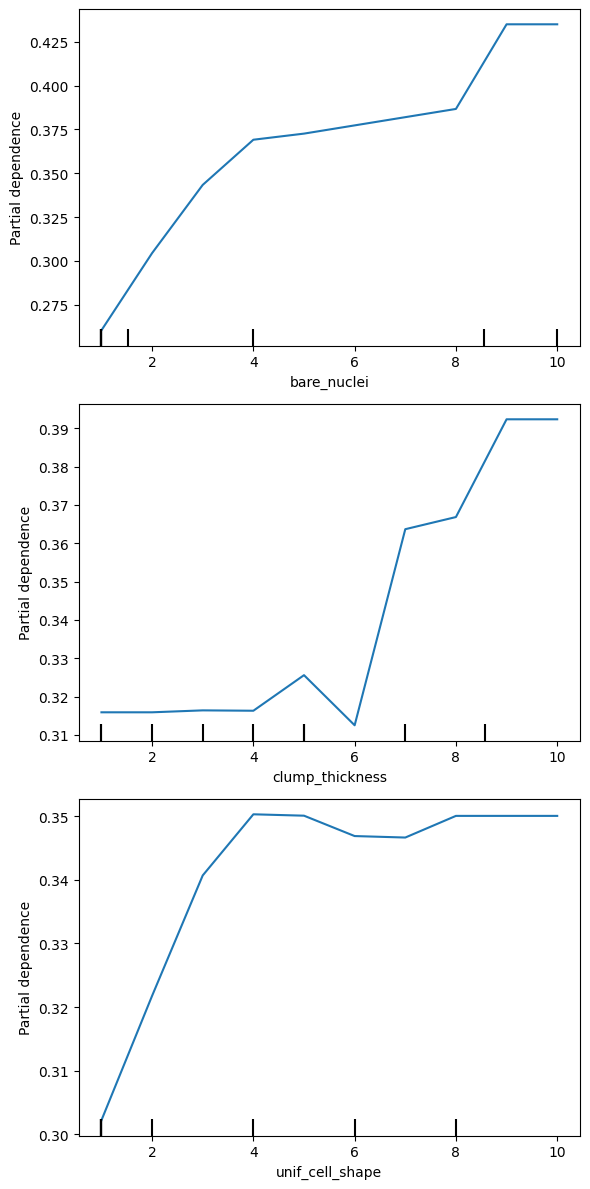

In [ ]:
perm = permutation_importance(fitted["xgb"], X_test, y_test,
                              n_repeats=20, random_state=42)

imp_df = pd.DataFrame({"feature": num_cols,
                       "importance": perm.importances_mean})
imp_df = imp_df.sort_values("importance", ascending=False)
display(imp_df.head(10))

top3 = imp_df["feature"].head(3).tolist()

fig, ax = plt.subplots(len(top3), 1, figsize=(6, 12))
for i, f in enumerate(top3):
    PartialDependenceDisplay.from_estimator(fitted["xgb"], X_test, [f], ax=ax[i])
plt.tight_layout()
plt.show()


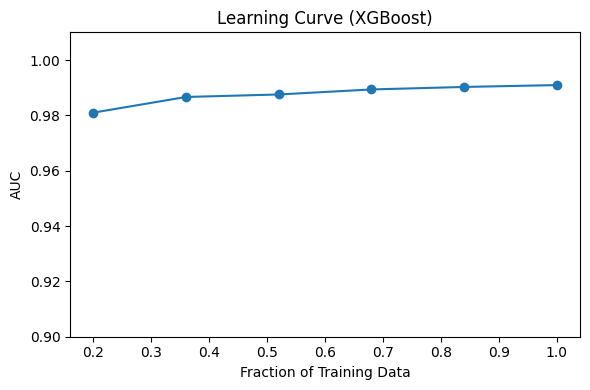

AUC values: [(np.float64(0.2), np.float64(0.9809782608695652)), (np.float64(0.36), np.float64(0.9866394927536232)), (np.float64(0.52), np.float64(0.9875452898550725)), (np.float64(0.6799999999999999), np.float64(0.989356884057971)), (np.float64(0.8400000000000001), np.float64(0.9902626811594203)), (np.float64(1.0), np.float64(0.9909420289855072))]


In [ ]:
sizes = np.linspace(0.2, 1.0, 6)
auc_list = []
base_xgb = fitted["xgb"]

for frac in sizes:
    if frac < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train,
            train_size=frac,
            stratify=y_train,
            random_state=42
        )
    else:
        # Use full training set when frac == 1.0
        X_sub, y_sub = X_train, y_train

    model = clone(base_xgb)
    model.fit(X_sub, y_sub)

    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    auc_list.append(auc)

plt.figure(figsize=(6, 4))
plt.plot(sizes, auc_list, marker='o')
plt.title("Learning Curve (XGBoost)")
plt.xlabel("Fraction of Training Data")
plt.ylabel("AUC")
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

print("AUC values:", list(zip(sizes, auc_list)))


In [ ]:
proba = fitted["xgb"].predict_proba(X_test)[:,1]
boot = []
rng = np.random.RandomState(42)

for _ in range(1000):
    idx = rng.randint(0, len(X_test), len(X_test))
    boot.append(roc_auc_score(y_test.iloc[idx], proba[idx]))

ci = np.percentile(boot, [2.5, 97.5])
print("95% Bootstrap CI for XGBoost AUC:", ci)


95% Bootstrap CI for XGBoost AUC: [0.97860793 0.99868929]
